<a href="https://colab.research.google.com/github/UsmanShaik1119/Hangman-Game/blob/main/ml_project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ML PROJECT-4

STATMENT(31):Diabetes Risk Assessment Agent

phase1


In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [ ]:
df = pd.read_csv("/content/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


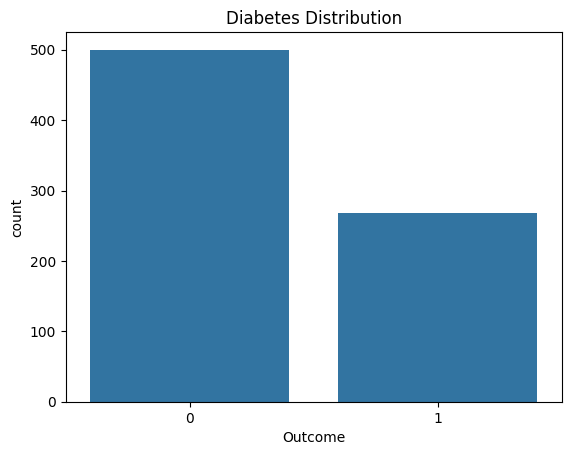

In [ ]:
sns.countplot(x=df["Outcome"])
plt.title("Diabetes Distribution")
plt.show()

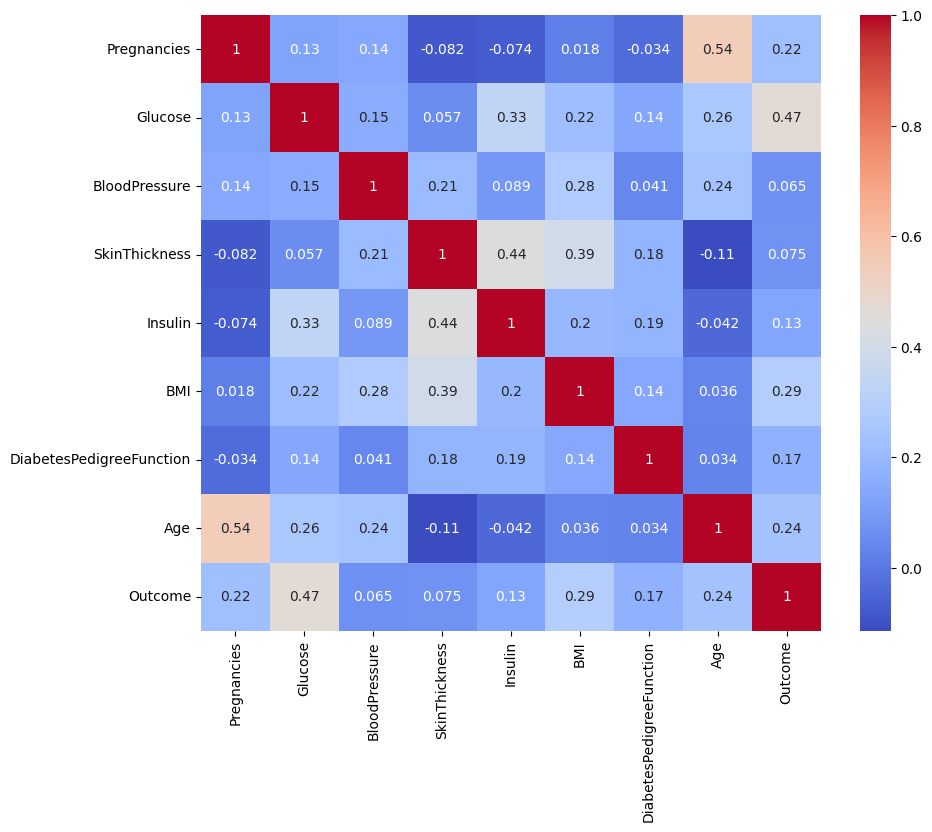

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [ ]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "MLP":
        MLPClassifier(
            hidden_layer_sizes=(100,50),
            max_iter=500,
            random_state=42
        )
}

In [ ]:
results = []

best_accuracy = 0

best_model = None

best_model_name = ""

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

    print("="*50)

    print(name)

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    print("ROC AUC  :", roc)

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")

    print(classification_report(y_test, y_pred))

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_model_name = name

Logistic Regression
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1 Score : 0.56
ROC AUC  : 0.8229629629629629

Confusion Matrix
[[82 18]
 [26 28]]

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

Random Forest
Accuracy : 0.7467532467532467
Precision: 0.6530612244897959
Recall   : 0.5925925925925926
F1 Score : 0.6213592233009708
ROC AUC  : 0.8146296296296297

Confusion Matrix
[[83 17]
 [22 32]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg   

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:03:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM
Accuracy : 0.7532467532467533
Precision: 0.66
Recall   : 0.6111111111111112
F1 Score : 0.6346153846153846
ROC AUC  : 0.7924074074074074

Confusion Matrix
[[83 17]
 [21 33]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

KNN
Accuracy : 0.7012987012987013
Precision: 0.5833333333333334
Recall   : 0.5185185185185185
F1 Score : 0.5490196078431373
ROC AUC  : 0.7404629629629629

Confusion Matrix
[[80 20]
 [26 28]]

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,SVM,0.753247,0.660000,0.611111,0.634615,0.792407
1,Random Forest,0.746753,0.653061,0.592593,0.621359,0.814630
2,XGBoost,0.740260,0.640000,0.592593,0.615385,0.806667
5,MLP,0.720779,0.590164,0.666667,0.626087,0.760185
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
4,KNN,0.701299,0.583333,0.518519,0.549020,0.740463


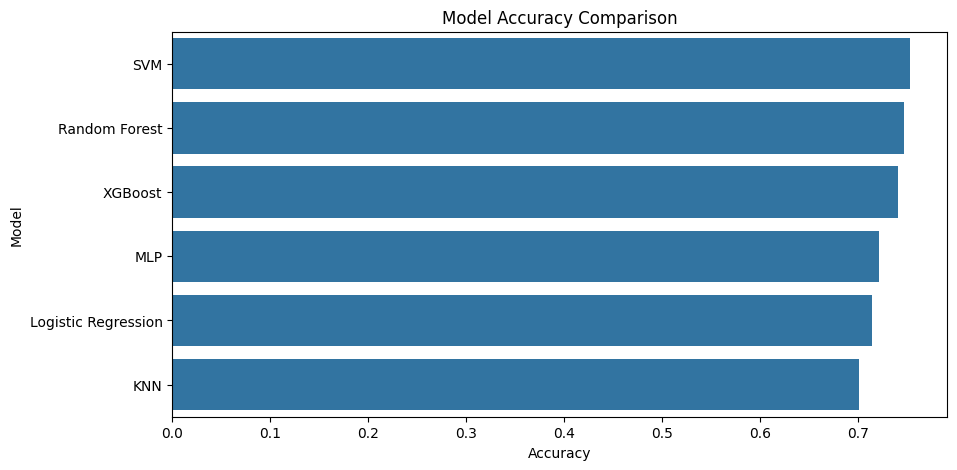

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results_df
)

plt.title("Model Accuracy Comparison")

plt.show()

In [ ]:
print("Best Model :", best_model_name)

print("Best Accuracy :", best_accuracy)

joblib.dump(best_model, "diabetes_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Best Model : SVM
Best Accuracy : 0.7532467532467533
Model Saved Successfully


In [ ]:
sample = np.array([[6,148,72,35,0,33.6,0.627,50]])

sample = scaler.transform(sample)

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")

Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


phase2

In [ ]:
!pip install streamlit pyngrok joblib scikit-learn xgboost -q

In [ ]:
from google.colab import files
uploaded = files.upload()  # select diabetes_model.pkl and scaler.pkl

Saving scaler (1).pkl to scaler (1) (1).pkl
Saving diabetes_model.pkl to diabetes_model (2).pkl


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import sqlite3
from datetime import datetime

# ---------------- Healthcare Monitoring Agent ----------------
class HealthMonitoringAgent:
    def __init__(self, model_path="diabetes_model.pkl", scaler_path="scaler.pkl", db_path="patient_monitoring.db"):
        self.model = joblib.load(model_path)
        self.scaler = joblib.load(scaler_path)
        self.db_path = db_path
        self.feature_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                               "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
        self._init_db()

    def _init_db(self):
        conn = sqlite3.connect(self.db_path)
        cur = conn.cursor()
        cur.execute("""
            CREATE TABLE IF NOT EXISTS patient_records (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                timestamp TEXT,
                patient_name TEXT,
                pregnancies INTEGER, glucose REAL, blood_pressure REAL,
                skin_thickness REAL, insulin REAL, bmi REAL,
                dpf REAL, age INTEGER,
                prediction INTEGER, risk_probability REAL,
                risk_level TEXT, recommendations TEXT
            )
        """)
        conn.commit()
        conn.close()

    def predict(self, patient_data: dict):
        row_df = pd.DataFrame([[patient_data[f] for f in self.feature_names]], columns=self.feature_names)
        scaled = self.scaler.transform(row_df)
        prediction = int(self.model.predict(scaled)[0])
        probability = float(self.model.predict_proba(scaled)[0][1])
        return {"prediction": prediction, "probability": probability, "risk_level": self._risk_level(probability)}

    def _risk_level(self, p):
        if p < 0.3: return "Low"
        elif p < 0.6: return "Moderate"
        elif p < 0.8: return "High"
        else: return "Very High"

    def generate_report(self, patient_data, result):
        notes = []
        if patient_data["Glucose"] >= 126:
            notes.append("Fasting glucose is in the diabetic range (>=126 mg/dL); confirmatory HbA1c/OGTT advised.")
        elif patient_data["Glucose"] >= 100:
            notes.append("Glucose is in the prediabetic range (100-125 mg/dL); monitor diet and retest.")
        if patient_data["BMI"] >= 30:
            notes.append("BMI indicates obesity (>=30); weight management recommended.")
        elif patient_data["BMI"] >= 25:
            notes.append("BMI indicates overweight (25-29.9); lifestyle adjustment advised.")
        if patient_data["BloodPressure"] >= 90:
            notes.append("Blood pressure is elevated; cardiovascular risk should be assessed.")
        if patient_data["Age"] >= 45:
            notes.append("Age >=45 is a non-modifiable risk factor; regular screening advised.")
        if patient_data["DiabetesPedigreeFunction"] >= 0.8:
            notes.append("Family history/genetic predisposition score is high.")

        general = {
            "Low": "Maintain a healthy lifestyle. Routine annual screening recommended.",
            "Moderate": "Adopt a balanced diet, increase physical activity, and retest glucose in 3-6 months.",
            "High": "Consult a physician for further evaluation, including an HbA1c test.",
            "Very High": "Urgent medical consultation recommended for immediate diagnostic testing."
        }
        text = general[result["risk_level"]]
        if notes:
            text += " Additional observations: " + " ".join(notes)
        return text

    def store_record(self, patient_name, patient_data, result, report):
        conn = sqlite3.connect(self.db_path)
        cur = conn.cursor()
        cur.execute("""
            INSERT INTO patient_records
            (timestamp, patient_name, pregnancies, glucose, blood_pressure, skin_thickness,
             insulin, bmi, dpf, age, prediction, risk_probability, risk_level, recommendations)
            VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        """, (datetime.now().strftime("%Y-%m-%d %H:%M:%S"), patient_name,
              patient_data["Pregnancies"], patient_data["Glucose"], patient_data["BloodPressure"],
              patient_data["SkinThickness"], patient_data["Insulin"], patient_data["BMI"],
              patient_data["DiabetesPedigreeFunction"], patient_data["Age"],
              result["prediction"], result["probability"], result["risk_level"], report))
        conn.commit()
        conn.close()

    def get_history(self, patient_name=None):
        conn = sqlite3.connect(self.db_path)
        if patient_name:
            df = pd.read_sql_query("SELECT * FROM patient_records WHERE patient_name = ? ORDER BY id DESC",
                                    conn, params=(patient_name,))
        else:
            df = pd.read_sql_query("SELECT * FROM patient_records ORDER BY id DESC", conn)
        conn.close()
        return df

# ---------------- Streamlit UI ----------------
st.set_page_config(page_title="Diabetes Risk Monitoring Agent", layout="wide")

@st.cache_resource
def load_agent():
    return HealthMonitoringAgent()

agent = load_agent()
st.title("🩺 AI Healthcare Monitoring Agent — Diabetes Risk")

page = st.sidebar.radio("Navigate", ["New Assessment", "Patient History", "Analytics Dashboard"])

if page == "New Assessment":
    st.subheader("Patient Record Entry")
    with st.form("patient_form"):
        col1, col2 = st.columns(2)
        with col1:
            patient_name = st.text_input("Patient Name / ID")
            pregnancies = st.number_input("Pregnancies", 0, 20, 1)
            glucose = st.number_input("Glucose (mg/dL)", 0, 300, 120)
            blood_pressure = st.number_input("Blood Pressure (mm Hg)", 0, 200, 70)
            skin_thickness = st.number_input("Skin Thickness (mm)", 0, 100, 20)
        with col2:
            insulin = st.number_input("Insulin (mu U/ml)", 0, 900, 80)
            bmi = st.number_input("BMI", 0.0, 70.0, 25.0)
            dpf = st.number_input("Diabetes Pedigree Function", 0.0, 3.0, 0.5)
            age = st.number_input("Age", 1, 120, 30)
        submitted = st.form_submit_button("Run Risk Assessment")

    if submitted:
        if not patient_name.strip():
            st.warning("Please enter a patient name/ID before submitting.")
        else:
            patient_data = {"Pregnancies": pregnancies, "Glucose": glucose, "BloodPressure": blood_pressure,
                             "SkinThickness": skin_thickness, "Insulin": insulin, "BMI": bmi,
                             "DiabetesPedigreeFunction": dpf, "Age": age}
            result = agent.predict(patient_data)
            report = agent.generate_report(patient_data, result)
            agent.store_record(patient_name, patient_data, result, report)

            st.markdown("---")
            c1, c2, c3 = st.columns(3)
            c1.metric("Prediction", "Diabetic" if result["prediction"] == 1 else "Not Diabetic")
            c2.metric("Risk Probability", f"{result['probability']*100:.1f}%")
            c3.metric("Risk Level", result["risk_level"])
            st.info(report)
            st.success("Record saved to patient monitoring database.")

elif page == "Patient History":
    st.subheader("Patient History Lookup")
    search_name = st.text_input("Search by Patient Name / ID (leave blank for all records)")
    history_df = agent.get_history(search_name if search_name.strip() else None)
    st.dataframe(history_df, use_container_width=True)
    if not history_df.empty:
        csv = history_df.to_csv(index=False).encode("utf-8")
        st.download_button("Download as CSV", csv, "patient_history.csv", "text/csv")

else:
    st.subheader("Analytics Dashboard")
    all_df = agent.get_history()
    if all_df.empty:
        st.info("No records yet. Run some assessments first.")
    else:
        c1, c2 = st.columns(2)
        c1.metric("Total Assessments", len(all_df))
        c1.metric("Diabetic Predictions", int((all_df["prediction"] == 1).sum()))
        c2.bar_chart(all_df["risk_level"].value_counts())
        st.markdown("#### Average Glucose by Risk Level")
        st.bar_chart(all_df.groupby("risk_level")["glucose"].mean())

Overwriting app.py


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3GJ7yZlPSoBbUuxnU9jS3E8eWYC_3QHPxq6NLyQwK9sjEASHX")

In [ ]:
from pyngrok import ngrok
import time

ngrok.kill()
get_ipython().system_raw("streamlit run app.py &>/content/logs.txt &")
time.sleep(5)

public_url = ngrok.connect(8501)
print("Your app is live at:", public_url)

Your app is live at: NgrokTunnel: "https://criteria-attest-viper.ngrok-free.dev" -> "http://localhost:8501"
